<a href="https://colab.research.google.com/github/BhavanaTK/ASL-Hand-Gesture-Detection-and-Speech-Conversion/blob/main/STUDY_1(TV_Sales_Prediction).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SIMPLE LINEAR REGRESSION

### Understanding data

In [ ]:
import pandas as pd

In [ ]:
# reading csv file
df1 =pd.read_csv(r"C:\Users\Admin\Downloads\tvmarketing.csv")
df1

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9
...,...,...
195,38.2,7.6
196,94.2,9.7
197,177.0,12.8
198,283.6,25.5


In [ ]:
# displaying first 5 raws
df1.head()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


In [ ]:
# displaying the last 5 raws
df1.tail()

,TV,Sales
195,38.2,7.6
196,94.2,9.7
197,177.0,12.8
198,283.6,25.5
199,232.1,13.4


In [ ]:
# to check the coloumns
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Sales   200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [ ]:
# to check the shape of the data frame
df1.shape

(200, 2)

In [ ]:
# statistical information about the dataframe
df1.describe()

,TV,Sales
count,200.000000,200.000000
mean,147.042500,14.022500
std,85.854236,5.217457
min,0.700000,1.600000
25%,74.375000,10.375000
50%,149.750000,12.900000
75%,218.825000,17.400000
max,296.400000,27.000000


## Visualizing data using plot

<Axes: xlabel='TV', ylabel='Sales'>

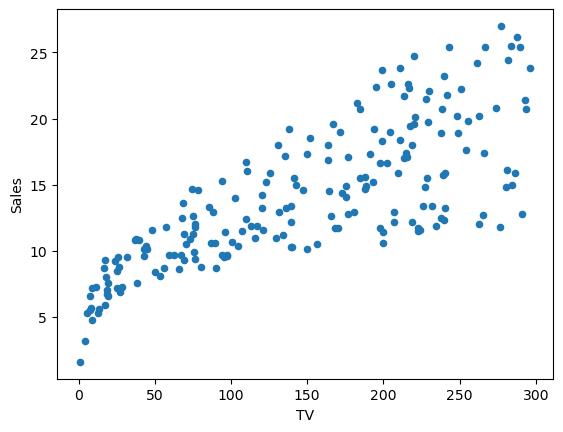

In [ ]:
# scatter plot
df1.plot(x="TV",y="Sales",kind="scatter")

### Preparing  X and Y

In [ ]:
# putting feature variable to x
X=df1["TV"]
# print first 5 rows
X.head()


0    230.1
1     44.5
2     17.2
3    151.5
4    180.8
Name: TV, dtype: float64

In [ ]:
# putting feature variable to y
Y=df1["Sales"]
# print first 5 rows
Y.head()


0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64

## Splitting datas in to Training and Testing datas


In [ ]:
#random_state is the seed used by the random number generator, it can be any integer.

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.85 , random_state=0000)

In [ ]:
print(type(X_train))
print(type(X_test))
print(type(Y_train))
print(type(Y_test))

<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


In [ ]:
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(170,)
(170,)
(30,)
(30,)


In [ ]:
#It is a general convention in scikit-learn that observations are rows, while features are columns.
#This is needed only when you are using a single feature; in this case, 'TV'.

import numpy as np
#Simply put, numpy.newaxis is used to increase the dimension of the existing array by one more dimension,
X_train=np.array(X_train)[:, np.newaxis]
X_test=np.array(X_test)[:, np.newaxis]

In [ ]:
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(170, 1)
(170,)
(30, 1)
(30,)


## Performing Linear Regression

In [ ]:
# import LinearRegression from sklearn
from sklearn.linear_model import LinearRegression

# Representing LinearRegression as lr(Creating LinearRegression Object)
lr = LinearRegression()

# Fit the model using lr.fit()
lr.fit(X_train, Y_train)

LinearRegression()

## Coefficients Calculation

In [ ]:
# Print the intercept and coefficients
print(lr.intercept_)
print(lr.coef_)

7.277401395470372
[0.04625785]


## Predictions

In [ ]:
# making predictions on the test sets
Y_pred = lr.predict(X_test)


In [ ]:
type(Y_pred)

numpy.ndarray

In [ ]:
Y_test.shape           # check the shape to generate the index for plot

(30,)

## Actual vs Predicted

Text(0, 0.5, 'Sales')

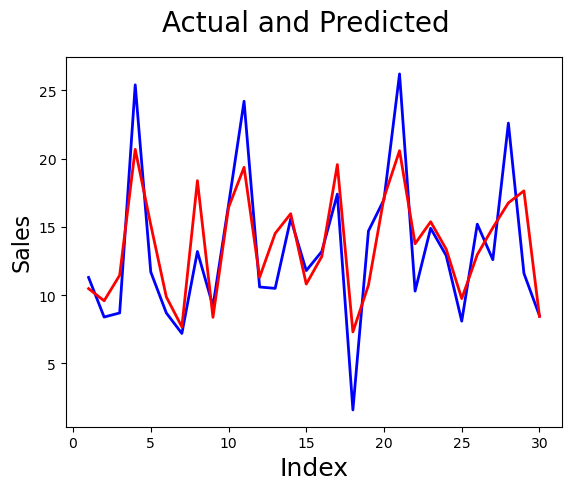

In [ ]:

import matplotlib.pyplot as plt
c = [i for i in range (1,31,1)]                               # generating index
fig = plt.figure()
plt.plot(c,Y_test, color="blue", linewidth=2, linestyle="-")
plt.plot(c,Y_pred, color="red",  linewidth=2, linestyle="-")
fig.suptitle('Actual and Predicted', fontsize=20)              # Plot heading
plt.xlabel('Index', fontsize=18)                               # X-label
plt.ylabel('Sales', fontsize=16)                               # Y-label

## Error Terms

Text(0, 0.5, 'ytest-ypred')

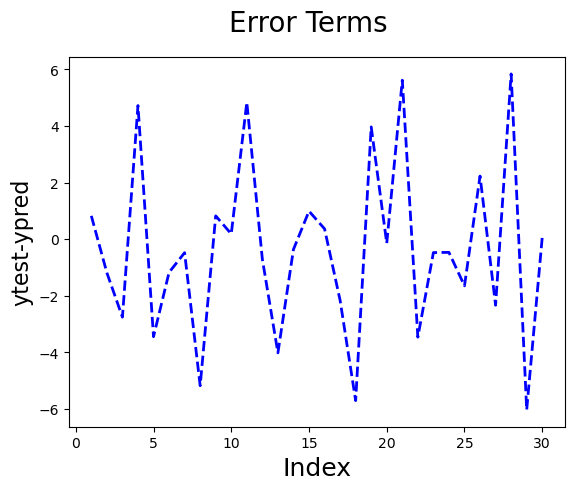

In [ ]:

c = [i for i in range(1,31,1)]
fig = plt.figure()
plt.plot(c,Y_test-Y_pred, color="blue", linewidth=2, linestyle="--")
fig.suptitle('Error Terms', fontsize=20)              # Plot heading
plt.xlabel('Index', fontsize=18)                      # X-label
plt.ylabel('ytest-ypred', fontsize=16)                # Y-label

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(Y_test, Y_pred)

In [ ]:
r_squared = r2_score(Y_test, Y_pred)

In [ ]:
print('Mean_Squared_Error :' ,mse)
print('r_square_value :',r_squared)

Mean_Squared_Error : 9.840800250242166
r_square_value : 0.6779572373473066


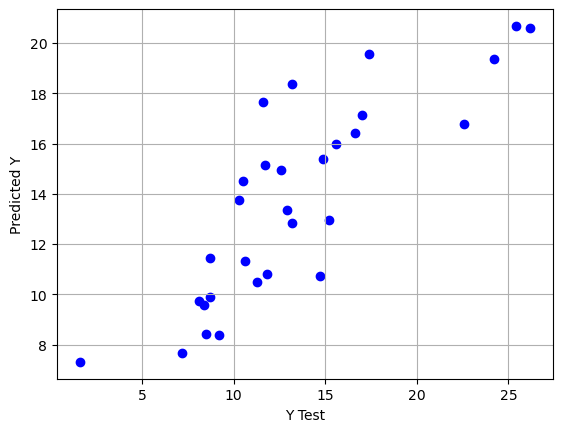

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(Y_test,Y_pred,c='blue')
plt.xlabel('Y Test')
plt.ylabel('Predicted Y')
plt.grid()
